In [83]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
import sys
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
project_root = Path.cwd().resolve().parents[2]
sys.path.append(str(project_root))

from defs.vae.ae import *
from defs.vae.training_defs import *
from defs.training_defs.loss import *
wavelengths = [str(w) for w in range(400, 2491, 10)]

In [85]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

out_layer = 64
spectra, fractions = load_spectral_data()
train_loader, val_loader = get_dataloaders(spectra, fractions, batch_size=1)
num_spectra = train_loader.dataset[0][0].size(0)
print(train_loader.batch_size)
print(num_spectra)

Device: cpu
1
210


In [ ]:
convolution = VCCAE([train_loader.batch_size, 512, 256, 128], [128, 128, 128, 128], c_d={'pad': 1}, num_spectra=num_spectra, out_layer=out_layer, ab_mlp = [3, 64, 64, 64])

ratio = 0.01 # Coefficient of spectral angle mapper (SAM) loss
sam_criterion = loss_mse_sam(ratio=ratio)

def criterion(estimated, actual, mu, variation):
    # pred_loss = nn.functional.mse_loss(estimated, actual[0])
    divergence = -0.5 * torch.sum(1 + variation - mu.pow(2) - variation.exp()) # Kullback-Leibler
    sam_loss = sam_criterion.calc(estimated, actual)
    return divergence + sam_loss

learning_rate = 1e-3
optimizer = optim.Adam(convolution.parameters(), lr=learning_rate)

n_epochs = 10

In [ ]:
train_losses = []
val_losses = []

for epoch in range(1, n_epochs+1):
    # Training loop
    convolution.train()
    tot_loss = 0
    for xb, yb in train_loader:
        # TODO: Add sample to separate csv file for training
        xb = xb.to(device)
        yb = yb.to(device)
        estimated, mu, variation = convolution(xb, yb)
        optimizer.zero_grad()
        loss_pred = criterion(estimated, xb, mu, variation)
        loss_pred.backward()
        optimizer.step()

        tot_loss += float(loss_pred)

    train_losses.append(tot_loss / len(train_loader.dataset))

    convolution.eval()
    tot_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            # TODO: Add sample to separate csv file for testing
            xb = xb.to(device)
            yb = yb.to(device)
            estimated, mu, variation = convolution(xb, yb)
            tot_val += criterion(estimated, xb, mu, variation) * xb.size(0)
    val_losses.append(tot_val / len(val_loader.dataset))

    print(f'Epoch {epoch}, loss: {tot_val/len(val_loader.dataset)}')

/Users/galacticmilk/Desktop/Michael's folder/[UNI]/[UTAT]/[science]/FINCH-Science_SyntheticData/defs/training_defs/loss.py:29: UserWarning: Using a target size (torch.Size([210])) that is different to the input size (torch.Size([1, 210])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_mse = F.mse_loss(x0_hat, x0)


Epoch 1, loss: 22.20691680908203
Epoch 2, loss: 22.45917320251465
Epoch 3, loss: 21.944826126098633
Epoch 4, loss: 22.37679672241211
Epoch 5, loss: 22.357650756835938
Epoch 6, loss: 21.983190536499023
Epoch 7, loss: 22.242923736572266
Epoch 8, loss: 22.175844192504883
Epoch 9, loss: 22.466901779174805
Epoch 10, loss: 22.196855545043945


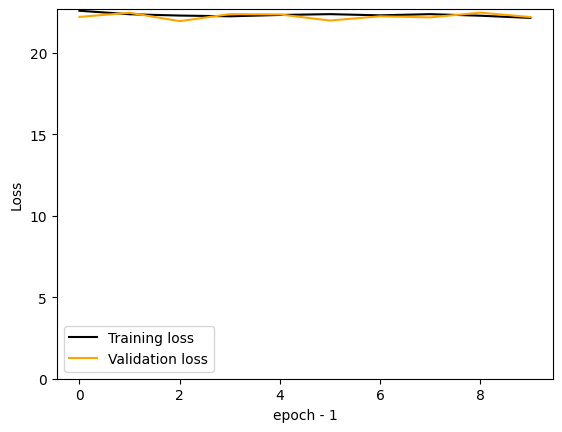

In [88]:
plt.plot(train_losses, color='black', label='Training loss')
plt.plot(val_losses, color='orange', label='Validation loss')
plt.ylim(0, max(max(train_losses), max(val_losses)) + 0.1)
plt.xlabel('epoch - 1'); plt.ylabel('Loss'); plt.legend()

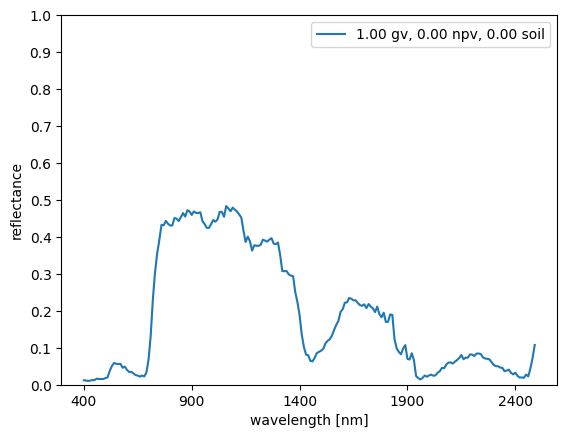

In [100]:
# Random spectrum generator! (Adopted from test.ipynb file)
rand_noise = torch.Tensor(np.random.random(out_layer)) # 1d array
tot_abundance = 1
gv = tot_abundance/np.random.randint(1, 10)
tot_abundance -= gv
npv = tot_abundance/np.random.randint(1, 10)
soil = tot_abundance - npv

gv = 1
npv = 0
soil = 0

abundance = [gv, npv, soil]
adjusted = convolution.conditioner(rand_noise, torch.Tensor(abundance))
produced_spectrum = convolution.decoder(adjusted)
produced_spectrum = produced_spectrum.detach().numpy()
rand_noise = np.asarray(rand_noise)
# print(rand_noise)
# print(produced_spectrum)
joined = np.concatenate((rand_noise, abundance, produced_spectrum))

# file.write(f'{joined[0]}')
# for i in joined[1:]:
#     file.write(f',{i}')
# file.write(f'\n')
plt.plot(wavelengths, produced_spectrum, label=f'{gv:.2f} gv, {npv:.2f} npv, {soil:.2f} soil')
plt.ylim(0, 1)
plt.xticks([i for i in range(0, 250, 50)])
plt.yticks([i/10 for i in range(0, 11)])
plt.legend()
plt.xlabel(f'wavelength [nm]')
plt.ylabel(f'reflectance')
plt.show()

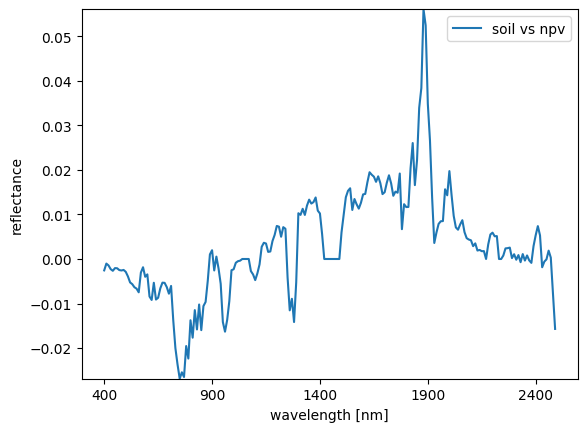

In [101]:
# Comparing two spectra's reflectances
rand_noise1 = torch.Tensor(np.random.random(out_layer)) # 1d array
rand_noise2 = torch.Tensor(np.random.random(out_layer)) # 1d array

# Spectrum 1
gv = 0
npv = 0
soil = 1

abundance = [gv, npv, soil]
adjusted = convolution.conditioner(rand_noise1, torch.Tensor(abundance))
produced_spectrum1 = convolution.decoder(adjusted)
produced_spectrum1 = produced_spectrum1.detach().numpy()

# Spectrum 2
gv = 0
npv = 1
soil = 0

abundance = [gv, npv, soil]
adjusted = convolution.conditioner(rand_noise2, torch.Tensor(abundance))
produced_spectrum2 = convolution.decoder(adjusted)
produced_spectrum2 = produced_spectrum2.detach().numpy()


# Difference
spectrum_difference = produced_spectrum2 - produced_spectrum1


plt.plot(wavelengths, spectrum_difference, label=f'soil vs npv')
plt.ylim(min(spectrum_difference), max(spectrum_difference))
plt.xticks([i for i in range(0, 250, 50)])
# plt.yticks([i/10 for i in range(0, 11)])
plt.legend()
plt.xlabel(f'wavelength [nm]')
plt.ylabel(f'reflectance')
plt.show()

In [ ]:
rand_noise = torch.Tensor(np.random.random(out_layer)) # random noise (Size must be specified to match decoder input layer)

gv = 0
npv = 0
soil = 1
abundance = [gv, npv, soil]

latent_vector = convolution.conditioner(rand_noise, torch.Tensor(abundance)) # Here we "concatenate" into a latent vector
produced_spectrum = convolution.decoder(latent_vector) # Here the sample is produced.